In [ ]:
import os
os.environ["OPENCV_IO_MAX_IMAGE_PIXELS"] = pow(2,40).__str__()

import ast
import torch
from torch.utils.data import DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, confusion_matrix

Image.MAX_IMAGE_PIXELS = pow(2,40)

from src.dataset import PatchDataset
from src.histology_feature_extractor import extract_features
from src.train_test import train_fusion, test_fusion_MIL, test_fusion
from utils.metrics import get_metrics
from utils.set_seed import seed_everything
from utils.load_model import load_histo_model

seed = 123
seed_everything(seed)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## 1. load pre-trained model and transformer

In [2]:
pretrained_model_name = ['uni', 'musk', 'phikon-v2', 'plip'][0]
pre_model, transform = load_histo_model(pretrained_model_name, device, ckpts_dir='./assets/ckpts')

In [3]:
# Training hyperparameters
adam_epochs = 500         # Number of epochs using Adam optimizer
adam_lr = 0.01            # Learning rate for Adam optimizer
lbfgs_epochs = 0          # Number of epochs using L-BFGS optimizer
lbfgs_lr = 1              # Learning rate for L-BFGS optimizer
use_bn = False            # Whether to use batch normalization
temperature = False       # Whether to add learnable temperature parameter

## 2. Prepare Dataset (for HCC)

### 2.1. Load data

In [4]:
dataset_path = "/path/to/HCC_HE"  # TODO: path to HCC_HE image directory
label_csv = "/path/to/metadata.csv"  # TODO: path to metadata.csv
anno_csv = "./data/microE_annotations/hcc_microE_anno_response_ALL.csv"   #  Signatures derived from MIF data using SPACE-GM

target_label = "response"
anno_col = "MICROE_GROUP"
anno_label = "MICROE_factor"
microe_factor = {
    "IA-S": 0,
    "Ly-T": 1,
    "My-T": 2,
    "Ec-T": 3,
    "T": 4,   # NST, non-specific tumor
    "LA": 5,
    "InterFace": 6,
}

In [ ]:
available_he = [f for f in os.listdir(dataset_path) 
                if f.startswith('HE-FinalLiv') and f.endswith('.jpg')]

target_df = pd.read_csv(label_csv)[['region_id', target_label]]
target_df.dropna(subset=[target_label], inplace=True)
target_df['he_region_id'] = 'HE-' + target_df['region_id'].astype(str) + '.jpg'
target_df = target_df[target_df['he_region_id'].isin(available_he)]

anno_df = pd.read_csv(anno_csv)
anno_df[anno_label] = anno_df[anno_col].map(microe_factor)
anno_df = anno_df.dropna(subset=[anno_label])
anno_df[anno_label] = anno_df[anno_label].astype(int)

df_merge = pd.merge(target_df, anno_df, left_on="region_id", right_on="ACQUISITION_ID", how="inner")
df_merge = df_merge.drop(columns=["ACQUISITION_ID"]).set_index("region_id", inplace=False)

df_merge['REGION'] = df_merge['ROI'].apply(ast.literal_eval)

print(f'Sample amount: {len(df_merge.index.unique())}, Patch amount: {len(df_merge)}')

Sample amount: 36, Patch amount: 100219


### 2.2. Split training and test sets for internal validation

In [6]:
from sklearn.model_selection import GroupShuffleSplit

groups = df_merge.index.unique()  # group by H&E region_id

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=seed)
train_groups, test_groups = next(gss.split(groups, groups=groups))

train_df = df_merge[df_merge.index.isin(groups[train_groups])]
test_df = df_merge[df_merge.index.isin(groups[test_groups])]
print(f'**Train** Sample amount: {len(train_df.index.unique())}, Patch amount: {len(train_df)}')
print(f'**Test** Sample amount: {len(test_df.index.unique())}, Patch amount: {len(test_df)}')

**Train** Sample amount: 25, Patch amount: 71203
**Test** Sample amount: 11, Patch amount: 29016


## 3. Internal validation

### 3.1 Training

In [7]:
# Training dataset
train_dataset = PatchDataset(img_names=train_df['he_region_id'].to_numpy(), 
                           target_labels=train_df[target_label].to_numpy(),
                           aux_labels=train_df[anno_label].to_numpy(),
                           transform=transform, 
                           dataset_dir=dataset_path,
                           is_crop=True, 
                           crop_range=train_df['REGION'].values,
                           return_region=False)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8)
train_features = extract_features(pre_model, pretrained_model_name, train_dataloader, device=device)
train_feats = train_features['embeddings']
train_aux_labels = train_features['aux_labels']
train_targets = train_features['labels']

# Train
fusion_model = train_fusion(train_feats, train_aux_labels, train_targets, device, 
                            adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_lr=adam_lr, lbfgs_lr=lbfgs_lr,
                            log_epoch=100, temperature=temperature, use_bn=use_bn)

extracting features: 100%|██████████| 4451/4451 [13:25<00:00,  5.53it/s]


[Adam] Train Epoch: 100 	 Aux Loss: 0.531739, Target Loss: 0.421535, Total Loss: 1.151958
[Adam] Train Epoch: 200 	 Aux Loss: 0.467426, Target Loss: 0.291776, Total Loss: 1.003128
[Adam] Train Epoch: 300 	 Aux Loss: 0.437727, Target Loss: 0.238187, Total Loss: 0.933292
[Adam] Train Epoch: 400 	 Aux Loss: 0.419704, Target Loss: 0.209487, Total Loss: 0.894299
[Adam] Train Epoch: 500 	 Aux Loss: 0.407342, Target Loss: 0.191173, Total Loss: 0.869875


### 3.2 Testing

In [8]:
sample_results = []
patch_results = {'target_prob': [], 'microE_pred': [], 'target_true': [], 'microE_true': []}

pids = test_df.index.unique()
for pid in pids:
    current_test_df = test_df[test_df.index == pid]
    current_test_dataset = PatchDataset(img_names=current_test_df['he_region_id'].to_numpy(), 
                                   target_labels=current_test_df[target_label].to_numpy(),
                                   aux_labels=current_test_df[anno_label].to_numpy(),
                                   transform=transform, 
                                   dataset_dir=dataset_path,
                                   is_crop=True, 
                                   crop_range=current_test_df['REGION'].values,
                                   return_region=False)
    current_test_dataloader = DataLoader(current_test_dataset, batch_size=16, shuffle=True, num_workers=8)
    current_test_features = extract_features(pre_model, pretrained_model_name, current_test_dataloader, device=device, show_progress=False)
    overfit_test_feats = current_test_features['embeddings']
    current_test_aux_labels = current_test_features['aux_labels']
    current_test_targets = current_test_features['labels']

    target_preds, target_probs, aux_preds, aux_probs = test_fusion(overfit_test_feats, fusion_model, device)
    assert len(target_probs.shape) == 1   # Binary classification
    target_prob = np.nanmedian(target_probs)
    target_pred = 0 if target_prob < 0.5 else 1

    current_test_label = current_test_targets[0]
    n_aux_classes = aux_probs.shape[1]
    total_patches = aux_probs.shape[0]
    test_aux_counts = [0] * n_aux_classes
    for pred, probs in zip(aux_preds, aux_probs):
        if probs[pred] > 0.6:
            test_aux_counts[pred] += 1 
    mean_aux_probs = np.mean(aux_probs, axis=0)
    assert len(test_aux_counts) == len(mean_aux_probs)
    for idx, (aux_count, aux_prob) in enumerate(zip(test_aux_counts, mean_aux_probs)):
        sample_results.append({'sample': pid,
                                    'target_label': current_test_label,
                                    'target_pred': target_pred,
                                    'target_prob': target_prob,
                                    'microE_label': idx,
                                    'microE_count': aux_count,
                                    'microE_prob': aux_prob,
                                    'microE_prop': aux_count / total_patches})
    
    aux_results = get_metrics(current_test_aux_labels, aux_preds, probs_all=None)
    print(f"{pid}: microE_ACC = {aux_results['acc']:.3f}, microE_Weighted_F1 = {aux_results['weighted_f1']:.3f}")
    patch_results['target_prob'].extend(target_probs)
    patch_results['microE_pred'].extend(aux_preds)
    patch_results['target_true'].extend(current_test_targets)
    patch_results['microE_true'].extend(current_test_aux_labels)


FinalLiv-27_c001_v001_r001_reg006: microE_ACC = 0.597, microE_Weighted_F1 = 0.596
FinalLiv-27_c001_v001_r001_reg007: microE_ACC = 0.669, microE_Weighted_F1 = 0.653
FinalLiv-27_c001_v001_r001_reg009: microE_ACC = 0.866, microE_Weighted_F1 = 0.885
FinalLiv-27_c001_v001_r001_reg013: microE_ACC = 0.411, microE_Weighted_F1 = 0.402
FinalLiv-27_c001_v001_r001_reg014: microE_ACC = 0.492, microE_Weighted_F1 = 0.459
FinalLiv-27_c001_v001_r001_reg015: microE_ACC = 0.506, microE_Weighted_F1 = 0.489
FinalLiv-27_c001_v001_r001_reg020: microE_ACC = 0.673, microE_Weighted_F1 = 0.669
FinalLiv-27_c002_v001_r001_reg006: microE_ACC = 0.599, microE_Weighted_F1 = 0.554
FinalLiv-27_c002_v001_r001_reg014: microE_ACC = 0.478, microE_Weighted_F1 = 0.492
FinalLiv-27_c002_v001_r001_reg015: microE_ACC = 0.449, microE_Weighted_F1 = 0.462
FinalLiv-27_c002_v001_r001_reg018: microE_ACC = 0.523, microE_Weighted_F1 = 0.546


### 3.3 Results analysis

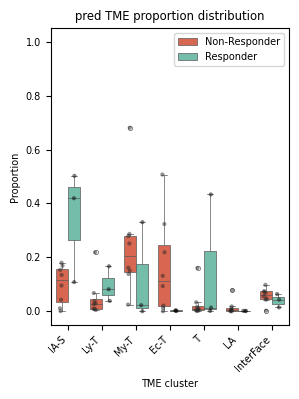

In [9]:
from matplotlib import rcParams

rcParams.update({"font.size": 7})

sample_results_df = pd.DataFrame(sample_results)
factor_microe = {v:k for k, v in microe_factor.items()}
sample_results_df['microE_label'] = sample_results_df['microE_label'].map(factor_microe)
sample_results_df['target_label'] = sample_results_df['target_label'].map({1.0: 'Responder', 0.0: 'Non-Responder'})


plt.figure(figsize=(3, 4))
x_label = 'microE_label'
y_label = 'microE_prop'
sns.boxplot(
    data=sample_results_df,
    x=x_label,  
    y=y_label,
    hue='target_label',  
    hue_order=['Non-Responder', 'Responder'], 
    palette={'Non-Responder': '#ed583a', 'Responder': '#69c9b1'},
    width=0.7,
    linewidth=0.5,
    flierprops={
        'markersize': 3,
        'markeredgewidth': 0.5,
    }
)
sns.stripplot(
    data=sample_results_df,
    x=x_label,  
    y=y_label,
    hue='target_label',
    hue_order=['Non-Responder', 'Responder'],
    size=3,
    palette='dark:k', 
    dodge=True, 
    legend=False,
    alpha=0.5)


title = f'pred TME proportion distribution'
plt.ylabel('Proportion')
plt.title(title)
plt.xlabel('TME cluster')
plt.xticks(rotation=45, ha='right')
plt.ylim(-0.05, 1.05)
plt.yticks([i/10 for i in range(0, 12, 2)])
plt.legend()
plt.tight_layout()
plt.show()

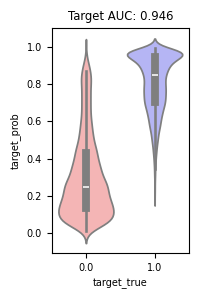

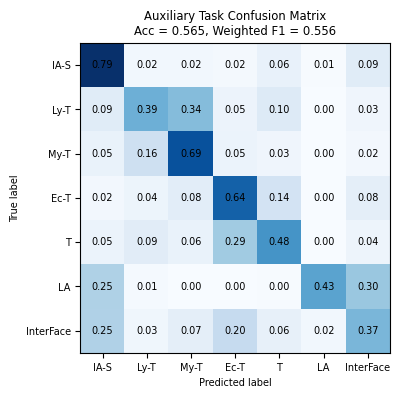

Baseline Acc = 0.187
Baseline Weighted F1 = 0.059


In [10]:
from sklearn.metrics import accuracy_score, f1_score
from matplotlib import rcParams

rcParams.update({"font.size": 7})

patch_results_df = pd.DataFrame(patch_results)
target_true = patch_results_df['target_true'].astype(int)
target_prob = patch_results_df['target_prob'].astype(float)
aux_true = patch_results_df['microE_true'].astype(int)
aux_pred = patch_results_df['microE_pred'].astype(int)

# Target task
m = roc_auc_score(target_true, target_prob)
plt.figure(figsize=(2, 3))
sns.violinplot(x='target_true', y='target_prob', hue='target_true', data=patch_results_df, palette='bwr_r')
plt.title(f'Target AUC: {m:.3f}')
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

# Auxiliary task
aux_acc = accuracy_score(aux_true, aux_pred)
aux_f1 = f1_score(aux_true, aux_pred, average='weighted')
conf_mat = confusion_matrix(aux_true, aux_pred, normalize='true')
plt.figure(figsize=(4, 4))
plt.imshow(conf_mat, cmap='Blues')
## Add text
for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        plt.text(j, i, "%.2f" % conf_mat[i, j], ha='center', va='center', color='k')
plt.xlabel('Predicted label')
plt.xticks(ticks=[i for i in range(len(microe_factor))], labels=microe_factor.keys())
plt.ylabel('True label')
plt.yticks(ticks=[i for i in range(len(microe_factor))], labels=microe_factor.keys())
plt.title(f'Auxiliary Task Confusion Matrix\nAcc = {aux_acc:.3f}, Weighted F1 = {aux_f1:.3f}')
plt.tight_layout()
plt.show()

# Aux Baseline
majority = np.bincount(aux_true).argmax()
aux_pred_majority = np.full_like(aux_true, majority)
print(f"Baseline Acc = {accuracy_score(aux_true, aux_pred_majority):.3f}")
print(f"Baseline Weighted F1 = {f1_score(aux_true, aux_pred_majority, average='weighted'):.3f}")